# Lab-7

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

###Load MNIST Dataset

In [21]:
batch_size = 128

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=True)

###Show Some Images From Dataset

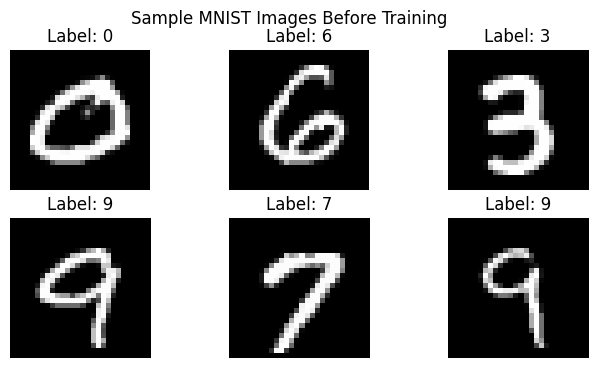

In [10]:
examples = enumerate(train_loader)
batch_idx, (example_data, example_targets) = next(examples)

plt.figure(figsize=(8,4))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(example_data[i][0], cmap='gray')
    plt.title(f"Label: {example_targets[i]}")
    plt.axis('off')

plt.suptitle("Sample MNIST Images Before Training")
plt.show()

The displayed images are samples from the MNIST handwritten digits dataset.

Each image is 28 × 28 pixels and represents digits from 0 to 9.

The labels above each image show the actual digit class.

This step helps us visually understand the dataset before training the model.

These images will later be used by the VAE to learn how to reconstruct digits.

###Dataset Graph

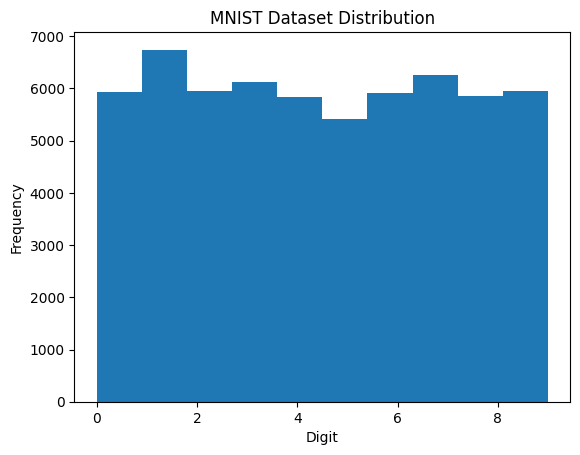

In [11]:
labels = train_dataset.targets.numpy()

plt.figure()
plt.hist(labels, bins=10)
plt.title("MNIST Dataset Distribution")
plt.xlabel("Digit")
plt.ylabel("Frequency")
plt.show()

The histogram shows the number of images available for each digit (0–9).

We can observe that the distribution is fairly balanced.

Each digit has approximately 5500–7000 samples.

Because the dataset is balanced, the model will learn all digits equally without bias.

###Build the VAE Model

In [12]:
class VAE(nn.Module):

    def __init__(self):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, 20)
        self.fc_logvar = nn.Linear(400, 20)

        self.fc3 = nn.Linear(20, 400)
        self.fc4 = nn.Linear(400, 784)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):
        h = self.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.relu(self.fc3(z))
        return self.sigmoid(self.fc4(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar

###Loss Function

In [13]:
def loss_function(recon_x, x, mu, logvar):

    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')

    KL = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return BCE + KL, BCE, KL

###Initialize Model

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VAE().to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)

###Training the Model

In [15]:
epochs = 10

loss_list = []

for epoch in range(epochs):

    total_loss = 0

    for data, _ in train_loader:

        data = data.view(-1,784).to(device)

        optimizer.zero_grad()

        recon_batch, mu, logvar = model(data)

        loss, recon_loss, kl_loss = loss_function(
            recon_batch, data, mu, logvar
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    loss_list.append(avg_loss)

    print(f"Epoch {epoch+1} Loss: {avg_loss:.4f}")

Epoch 1 Loss: 165.9170
Epoch 2 Loss: 121.7457
Epoch 3 Loss: 114.7784
Epoch 4 Loss: 111.8112
Epoch 5 Loss: 110.0660
Epoch 6 Loss: 108.8877
Epoch 7 Loss: 108.0874
Epoch 8 Loss: 107.4274
Epoch 9 Loss: 106.9152
Epoch 10 Loss: 106.4732


The loss value decreases with each epoch.

This means the model is learning to reconstruct images better over time.

At the beginning, the loss is high because the model has not learned the patterns yet.

As training continues, the model improves its reconstruction ability, reducing the loss.

###Training Loss Graph

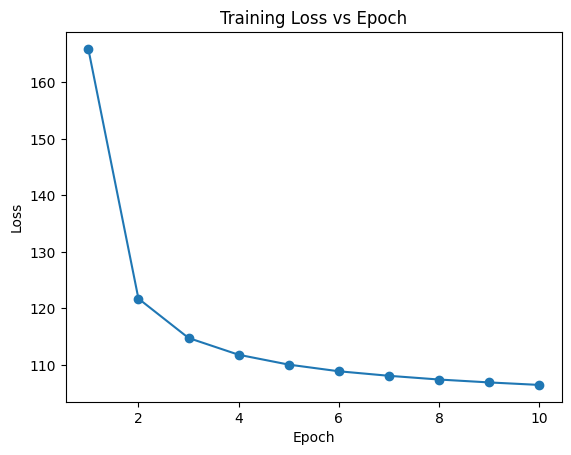

In [16]:
plt.figure()

plt.plot(range(1, epochs+1), loss_list, marker='o')

plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

The graph shows Loss vs Epoch.

We can clearly see a downward trend.

This indicates the model is converging and learning meaningful latent representations.

The curve starts high and gradually stabilizes around ~106 loss.

###Testing the Model

In [17]:
data_iter = iter(test_loader)
test_images, labels = next(data_iter)

test_images = test_images.view(-1,784).to(device)

with torch.no_grad():
    reconstructed, _, _ = model(test_images)

###Show Original vs Reconstructed Images

In [33]:
import random

# Select random indices
indices = random.sample(range(len(test_dataset)), 10)

test_images = torch.stack([test_dataset[i][0] for i in indices])
labels = [test_dataset[i][1] for i in indices]

test_images = test_images.view(-1,784).to(device)

with torch.no_grad():
    reconstructed, _, _ = model(test_images)

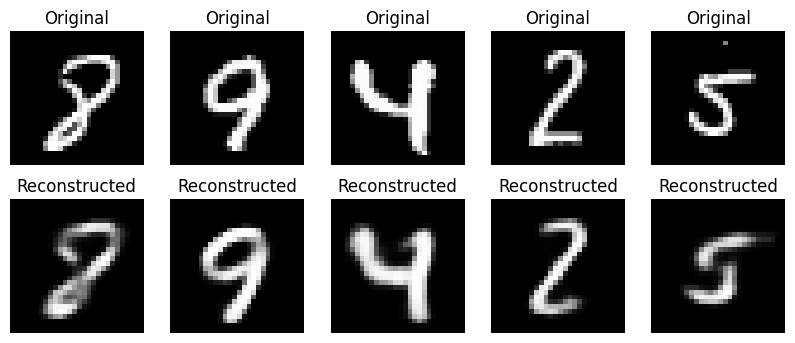

In [34]:
test_images = test_images.cpu().view(-1,28,28)
reconstructed = reconstructed.cpu().view(-1,28,28)

plt.figure(figsize=(10,4))

for i in range(5):

    # Original
    plt.subplot(2,5,i+1)
    plt.imshow(test_images[i], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(2,5,i+6)
    plt.imshow(reconstructed[i], cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

The top row shows the original images from the dataset.

The bottom row shows the reconstructed images produced by the VAE.

The reconstructed digits are slightly blurry, which is normal for VAEs.

Despite the blur, the digits are still recognizable and similar to the original images.

###Latent Space Visualization

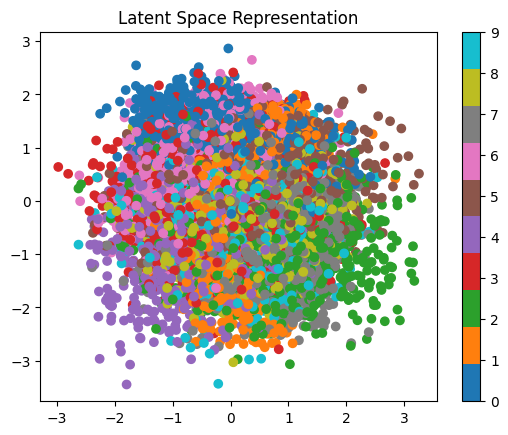

In [19]:
latent_vectors = []
digit_labels = []

with torch.no_grad():

    for data, labels in test_loader:

        data = data.view(-1,784).to(device)

        mu, logvar = model.encode(data)

        latent_vectors.append(mu.cpu().numpy())
        digit_labels.append(labels.numpy())

latent_vectors = np.concatenate(latent_vectors)
digit_labels = np.concatenate(digit_labels)

plt.figure()

scatter = plt.scatter(
    latent_vectors[:,0],
    latent_vectors[:,1],
    c=digit_labels,
    cmap='tab10'
)

plt.colorbar(scatter)
plt.title("Latent Space Representation")
plt.show()

This scatter plot shows how the VAE represents images in the latent space.

Each point represents one image from the dataset.

Different colors correspond to different digits (0–9).

Similar digits tend to appear closer together in the latent space.